# 03 · Baseline Walk-Forward Backtest
### S&P 500 Pairs Trading: Research Pipeline


**Objective:** Run a yearly equal-weight walk-forward backtest on different methods and compare results.

**Walk-forward rule:** For trading year T, fit on T-1, trade on T.

In [1]:
import sys
import warnings
from pathlib import Path
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
 
# ── path setup ────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve().parent   # adjust if your notebooks/ is elsewhere
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")
 
# ── project imports ───────────────────────────────────────────────────────────
from statarb.context  import AppContext
from statarb.pipeline import BaselinePipelineV0
from statarb.metrics  import get_backtest_metrics, save_strategy_outputs
from statarb.backtest import make_daily_rates
 
# ── shared context ────────────────────────────────────────────────────────────
ctx = AppContext.instance(config_path=str(PROJECT_ROOT / "config.yaml"))
cfg = ctx.cfg
 
OUTPUT_DIR = Path(cfg["data"]["output_dir"])
TEST_DIR   = Path(cfg["data"]["test_dir"])
PLOT_DIR   = Path(cfg["data"]["plot_dir"])
TEST_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
 
# ── visual style ──────────────────────────────────────────────────────────────
METHODS = ["corr", "dist", "coint", "combined"]

COLORS  = {"corr": "#2196F3", "dist": "#FF9800", "coint": "#4CAF50", "combined": "#E53935"}
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})


## 1 · Pair Counts per Method per Year

Before running the backtest, verify how many pairs each method produced
for each trading year.

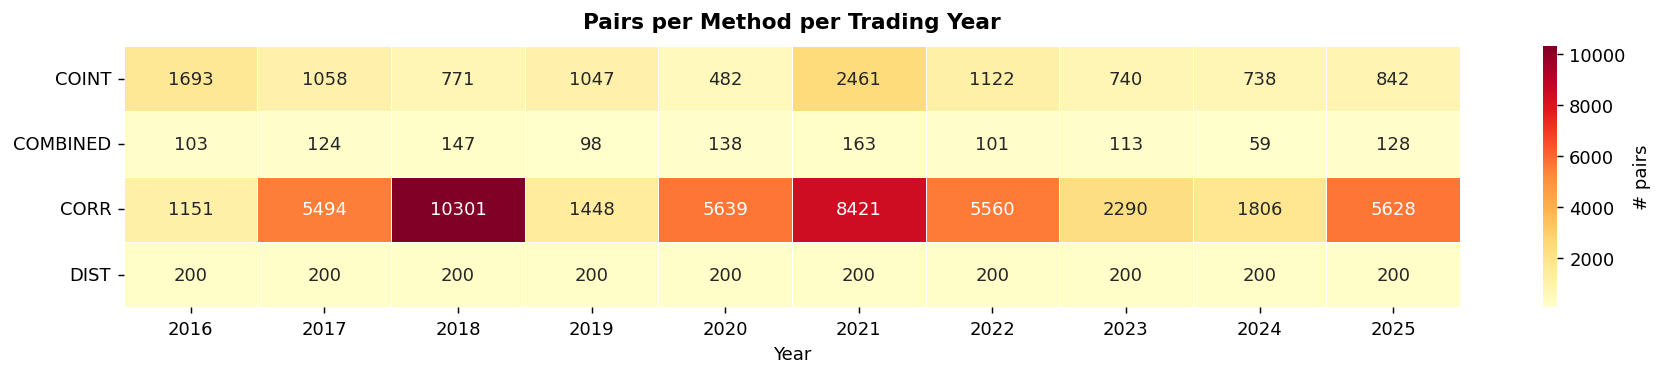

In [2]:
records = []
for method in METHODS:
    for f in sorted(OUTPUT_DIR.glob(f"pairs_{method}_*.parquet")):
        year = int(f.stem.split("_")[-1][:4])
        n    = len(pd.read_parquet(f))
        records.append({"Method": method.upper(), "Year": year, "Pairs": n})
 
df_counts = pd.DataFrame(records)
pivot = df_counts.pivot(index="Method", columns="Year", values="Pairs").fillna(0).astype(int)
 
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.4, cbar_kws={"label": "# pairs"}, ax=ax)
ax.set_title("Pairs per Method per Trading Year", fontsize=12, fontweight="bold", pad=10)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_pair_counts.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 · Run Baseline Backtest

In [3]:
pipeline = BaselinePipelineV0(cfg, ctx)
results  = {}   
 
for method in METHODS:
    metrics_path       = TEST_DIR / f"backtest_baselineV0_no_tx_metrics_{method}.parquet"
    returns_path       = TEST_DIR / f"backtest_baselineV0_no_tx_returns_{method}.parquet"
    pairs_attr_path    = TEST_DIR / f"backtest_baselineV0_no_tx_pairs_attr_{method}.parquet"
    pairs_metrics_path = TEST_DIR / f"backtest_baselineV0_no_tx_pairs_metrics_{method}.parquet"

    # ── load cache if available ───────────────────────────────────────────────
    if (metrics_path.exists() and returns_path.exists() and 
        pairs_attr_path.exists() and pairs_metrics_path.exists()):

        df_m = pd.read_parquet(metrics_path)
        df_r = pd.read_parquet(returns_path)
        df_pa_ret = pd.read_parquet(pairs_attr_path)
        df_pa_met = pd.read_parquet(pairs_metrics_path)
        print(f"[{method.upper():8s}] loaded from cache")
        
        results[method] = (df_m, df_r, {
            "per_pair_returns": df_pa_ret,
            "per_pair_metrics": df_pa_met
        })
        continue
 
    # ── run pipeline ──────────────────────────────────────────────────────────
    print(f"\n{'='*60}\n  Running {method.upper()}\n{'='*60}")
    df_m, df_r, df_a = pipeline.run_method(method)
    results[method] = (df_m, df_r, df_a)
 
    if not df_m.empty:
        save_strategy_outputs(
            backtest_records     = df_m,
            pair_returns         = df_r,
            pair_attributes_dict = df_a, 
            metrics_path         = str(metrics_path),
            returns_path         = str(returns_path),
            pairs_attr_path      = str(pairs_attr_path), 
            pairs_metrics_path   = str(pairs_metrics_path),
        )
        print(f"\n  Saved → {metrics_path.name}   ({len(df_m)} years)")
        print(f"  Saved → {returns_path.name}    ({df_r.shape[0]} days × {df_r.shape[1]} cols)")
        print(f"  Saved → {pairs_attr_path.name}  (Individual asset attribution records)")
    else:
        print(f"\n  WARNING: no results for {method}")
 
print("\nAll methods complete.")

[CORR    ] loaded from cache
[DIST    ] loaded from cache
[COINT   ] loaded from cache
[COMBINED] loaded from cache

All methods complete.


## 3 · Growth of $1 — Baseline Performance Comparison

Equal-weight portfolio equity curve for each method.
Y-axis is log-scaled so percentage moves are visually comparable across
the full 10-year horizon.

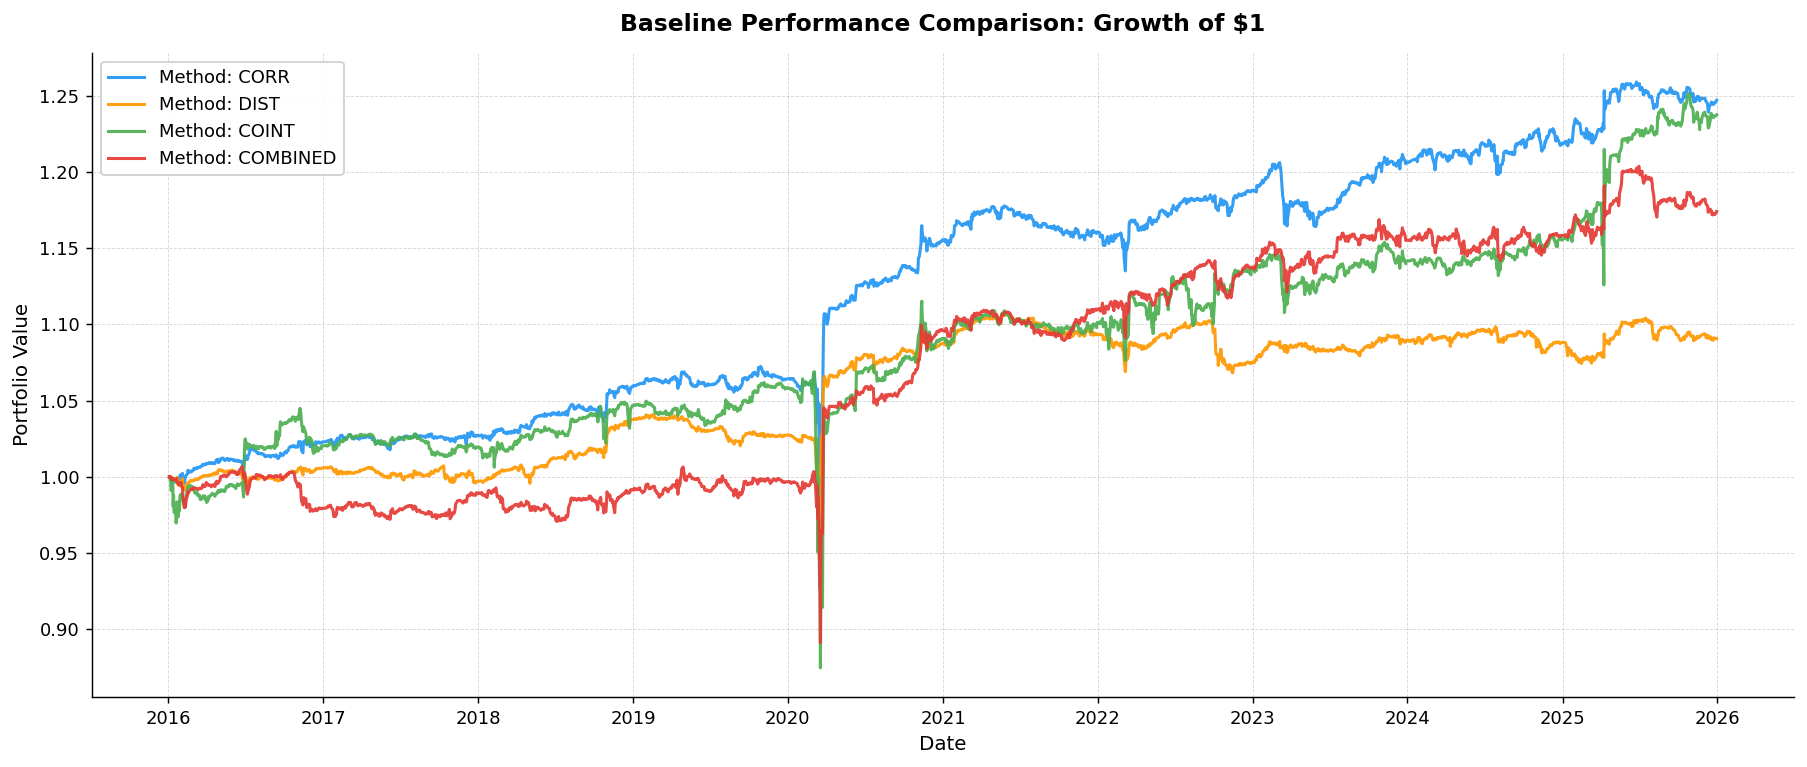

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
 
for method in METHODS:
    df_m, df_r, _ = results[method]
    if df_r.empty:
        continue
    equity = df_r.sum(axis=1).cumsum().apply(np.exp)
    ax.plot(equity.index, equity.values,
            label=f"Method: {method.upper()}",
            color=COLORS[method], linewidth=1.7, alpha=0.92)
 

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)
ax.set_title("Baseline Performance Comparison: Growth of $1",
             fontweight="bold",fontsize=13, pad=12)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Portfolio Value",fontsize=11)
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_growth_of_1.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Drawdown Comparison

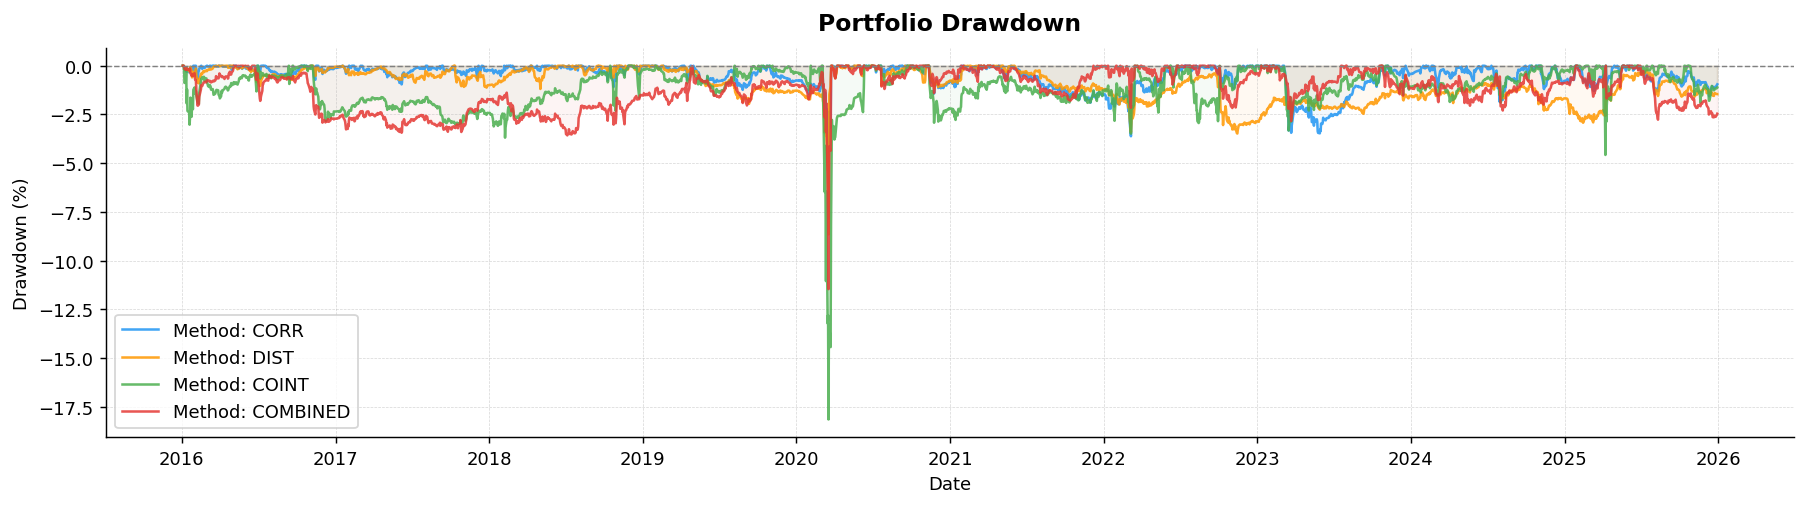

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))

for method in METHODS:
    df_metrics, df_returns, _ = results[method]
    if df_returns.empty:
        continue
    equity_dollar = df_returns.sum(axis=1).cumsum().apply(np.exp)
    drawdown = (equity_dollar / equity_dollar.cummax()) - 1  
    drawdown_pct = drawdown * 100                           
    ax.plot(drawdown_pct.index, drawdown_pct.values,
            label=f"Method: {method.upper()}",
            color=COLORS[method], linewidth=1.4, alpha=0.85)
    ax.fill_between(drawdown_pct.index, drawdown_pct.values, 0,
                    alpha=0.05, color=COLORS[method])

ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Portfolio Drawdown", fontsize=13, fontweight="bold",pad=10)
ax.set_ylabel("Drawdown (%)") 
ax.set_xlabel("Date")
ax.legend(loc="lower left", fontsize=10)
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_drawdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · Portfolio-Level Performance Metrics

In [6]:
summary_rows = []
 
for method in METHODS:
    df_m, df_r, _ = results[method]
    if df_r.empty:
        continue
 
    # 1. Reconstruct the continuous whole-period equity curve
    net_returns = df_r.sum(axis=1)
    equity      = net_returns.cumsum().apply(np.exp).rename("EquityCurve").to_frame()
    
    # 2. Get the risk-free rate aligned to this continuous timeline
    df_rates    = make_daily_rates(cfg, equity.index)
 
    # 3. Calculate true institutional metrics on the continuous 10-year curve
    m = get_backtest_metrics(equity, risk_free_rate=df_rates["rfr"])
 
    # 4. Extract Total Trades by summing across the yearly records
    if "Total Trades" in df_m.columns:
        m["Total Trades"] = int(df_m["Total Trades"].sum())
    else:
        m["Total Trades"] = 0
 
    m["Method"] = method.upper()
    summary_rows.append(m)
 
METRIC_COLS = [
    "Sharpe Ratio", "Annual Excess Return", "Annual Volatility",
    "Maximum Drawdown (MDD)", "Calmar Ratio", "Sortino Ratio",
    "Win Rate", "Longest Drawdown Duration", "Total Trades",
]
FMT = {
    "Sharpe Ratio":              "{:.3f}",
    "Annual Excess Return":      "{:.2%}",
    "Annual Volatility":         "{:.2%}",
    "Maximum Drawdown (MDD)":    "{:.2%}",
    "Calmar Ratio":              "{:.3f}",
    "Sortino Ratio":             "{:.3f}",
    "Win Rate":                  "{:.2%}",
    "Longest Drawdown Duration": "{:.0f} days",
    "Total Trades":              "{:.0f}",
}
 
if summary_rows:
    df_summary = pd.DataFrame(summary_rows).set_index("Method")
    valid_cols = [c for c in METRIC_COLS if c in df_summary.columns]
    df_summary = df_summary[valid_cols]
 
    display(
        df_summary.style
        .format({k: v for k, v in FMT.items() if k in df_summary.columns})
        .background_gradient(
            subset=[c for c in ["Sharpe Ratio", "Calmar Ratio", "Sortino Ratio"]
                    if c in df_summary.columns],
            cmap="RdYlGn"
        )
        .set_caption("Baseline_V1 Walk-Forward — Consolidated Portfolio Metrics (Continuous)")
    )

,Sharpe Ratio,Annual Excess Return,Annual Volatility,Maximum Drawdown (MDD),Calmar Ratio,Sortino Ratio,Win Rate,Longest Drawdown Duration,Total Trades
Method,,,,,,,,,
CORR,0.666,2.21%,3.32%,-8.17%,0.271,0.853,51.81%,274 days,2811599
DIST,0.294,0.87%,2.95%,-9.05%,0.096,0.360,52.13%,1149 days,117051
COINT,0.308,2.14%,6.92%,-20.03%,0.107,0.344,50.82%,487 days,636378
COMBINED,0.374,1.61%,4.31%,-12.18%,0.132,0.456,51.33%,943 days,70096


## 6 · Year-by-Year Sharpe Heatmap

Does performance persist across years or is it concentrated in a few regimes?

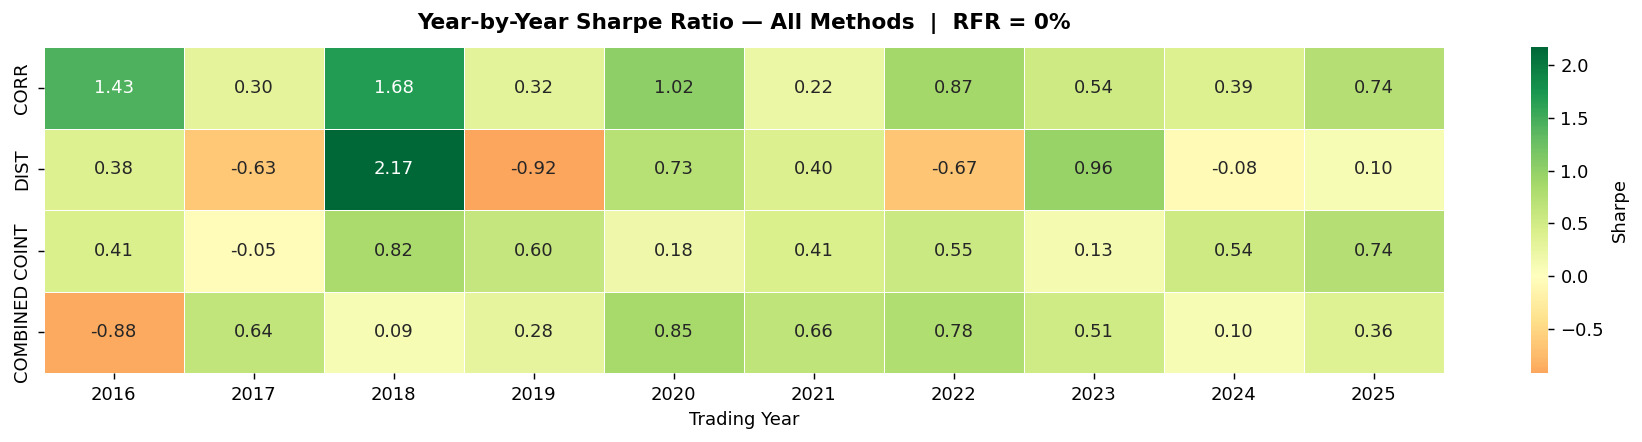

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
CORR,1.43,0.30,1.68,0.32,1.02,0.22,0.87,0.54,0.39,0.74
DIST,0.38,-0.63,2.17,-0.92,0.73,0.40,-0.67,0.96,-0.08,0.10
COINT,0.41,-0.05,0.82,0.60,0.18,0.41,0.55,0.13,0.54,0.74
COMBINED,-0.88,0.64,0.09,0.28,0.85,0.66,0.78,0.51,0.10,0.36


In [7]:
yearly_sharpe = {m.upper(): {} for m in METHODS}
 
for method in METHODS:
    df_m, df_r, _ = results[method]
    if df_m.empty:
        continue
    
    # df_m index is the string year (e.g., '2026')
    for year_str in df_m.index:
        year_int = int(year_str)
        s = df_m.loc[year_str, "Sharpe Ratio"]
        yearly_sharpe[method.upper()][year_int] = round(float(s), 2) if np.isfinite(s) else np.nan
 
df_ys = pd.DataFrame(yearly_sharpe).T.sort_index(axis=1)
 
fig, ax = plt.subplots(figsize=(14, 3.5))
sns.heatmap(
    df_ys.astype(float), annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.4,
    cbar_kws={"label": "Sharpe"}, ax=ax
)
ax.set_title("Year-by-Year Sharpe Ratio — All Methods  |  RFR = 0%",
             fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Trading Year"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_yearly_sharpe.png", dpi=150, bbox_inches="tight")
plt.show()
display(df_ys)

## 7 · Per-Pair Sharpe Distribution

How spread out is performance across individual pairs within each method?
A wide distribution means a few pairs drive most of the return.

In [8]:
print("Capital Deployment Check")
print("=" * 55)
print(f"{'Method':<10} {'Yrs':>4}  {'Pairs/Yr (avg)':>14}  {'Weight/Pair':>12}")
print("-" * 55)
 
for method in METHODS:
    df_m, df_r, _ = results[method]
    if df_r.empty:
        print(f"  {method.upper():<8}  no data")
        continue
 
    # Count years directly from the metrics index lengths
    n_years = len(df_m)
 
    # Estimate avg pairs per year from pair count files
    pair_counts = []
    for f in sorted(OUTPUT_DIR.glob(f"pairs_{method}_*.parquet")):
        year = int(f.stem.split("_")[-1][:4])
        if 2016 <= year <= 2025:
            pair_counts.append(len(pd.read_parquet(f)))
 
    avg_pairs = np.mean(pair_counts) if pair_counts else 0
    weight    = 1.0 / avg_pairs if avg_pairs > 0 else 0
 
    print(f"  {method.upper():<8}  {n_years:>3}  {avg_pairs:>14.1f}  {weight:>11.2%}")

Capital Deployment Check
Method      Yrs  Pairs/Yr (avg)   Weight/Pair
-------------------------------------------------------
  CORR       10          4773.8        0.02%
  DIST       10           200.0        0.50%
  COINT      10          1095.4        0.09%
  COMBINED   10           117.4        0.85%


## 8 · Top and Bottom Pairs

Which individual pairs drove the most and least value?

In [9]:
print("=" * 70)
print("  BASELINE COMPLETE: PORTFOLIO & SINGLE-PAIR ATTRIBUTION")
print("=" * 70)
print(f"{'Method':<12} {'Years':>6}  {'Days':>6}  {'Total Return':>13}")
print(f"{'-'*12:<12} {'------':>6}  {'------':>6}  {'-------------':>13}")
 
for method in METHODS:
    df_m, df_r, df_a = results[method]
    if df_r.empty:
        print(f"  {method.upper():<12}  NO RESULTS")
        continue
        
    # Reconstruct whole-period portfolio metrics
    equity       = df_r.sum(axis=1).cumsum().apply(np.exp)
    total_return = equity.iloc[-1] - 1.0
    n_years      = len(df_m)
    n_days       = df_r.shape[0]
    
    print(f"  {method.upper():<12} {n_years:>6}  {n_days:>6}  {total_return:>+13.2%}")
    
    # Extract the individual pair records generated during execution
    df_pair_metrics = df_a.get("per_pair_metrics", pd.DataFrame())
    
    if not df_pair_metrics.empty:
        # We rank by Sharpe Ratio or Annual Excess Return
        rank_col = "Sharpe Ratio"
        df_sorted = df_pair_metrics.sort_values(by=rank_col, ascending=False)
        
        # Display Top 3 Best Alpha Generating Pairs
        print("     ▲ Top 3 Best Performing Pairs:")
        for _, row in df_sorted.head(3).iterrows():
            pair_label = f"{row['ticker1']}-{row['ticker2']}"
            sharpe = row["Sharpe Ratio"]
            pnl = row["Annual Excess Return"]
            trades = row["Total Trades"]
            print(f"       • {pair_label:<10} -> Sharpe: {sharpe:5.2f} | Return: {pnl:+7.2%} | Trades: {int(trades)}")
            
        # Display Bottom 3 Worst Underperforming Pairs
        print("     ▼ Bottom 3 Worst Performing Pairs:")
        for _, row in df_sorted.tail(3).iloc[::-1].iterrows(): # Reverse layout order
            pair_label = f"{row['ticker1']}-{row['ticker2']}"
            sharpe = row["Sharpe Ratio"]
            pnl = row["Annual Excess Return"]
            trades = row["Total Trades"]
            print(f"       • {pair_label:<10} -> Sharpe: {sharpe:5.2f} | Return: {pnl:+7.2%} | Trades: {int(trades)}")
    else:
        print("     No single-pair tracking metrics found for this method.")
    print("-" * 70)

  BASELINE COMPLETE: PORTFOLIO & SINGLE-PAIR ATTRIBUTION
Method        Years    Days   Total Return
------------ ------  ------  -------------
  CORR             10    2513        +24.69%
     ▲ Top 3 Best Performing Pairs:
       • JPM-SYF    -> Sharpe:  3.51 | Return: +24.86% | Trades: 33
       • BDX-COO    -> Sharpe:  3.37 | Return: +19.95% | Trades: 43
       • ANET-MSCI  -> Sharpe:  3.27 | Return: +34.42% | Trades: 29
     ▼ Bottom 3 Worst Performing Pairs:
       • LII-TJX    -> Sharpe:   nan | Return:  +0.00% | Trades: 0
       • COST-JPM   -> Sharpe:   nan | Return:  +0.00% | Trades: 0
       • CMS-ETR    -> Sharpe:   nan | Return:  +0.00% | Trades: 0
----------------------------------------------------------------------
  DIST             10    2513         +9.06%
     ▲ Top 3 Best Performing Pairs:
       • NSC-REG    -> Sharpe:  2.73 | Return: +23.43% | Trades: 40
       • AIG-PRU    -> Sharpe:  2.73 | Return: +15.39% | Trades: 26
       • DTE-FE     -> Sharpe:  2.68 | Retu